In [1]:
# data preprocessing 

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('iris')

encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
df = df[df['species'] != 0]
df = df[['sepal_width', 'petal_length', 'species']]
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


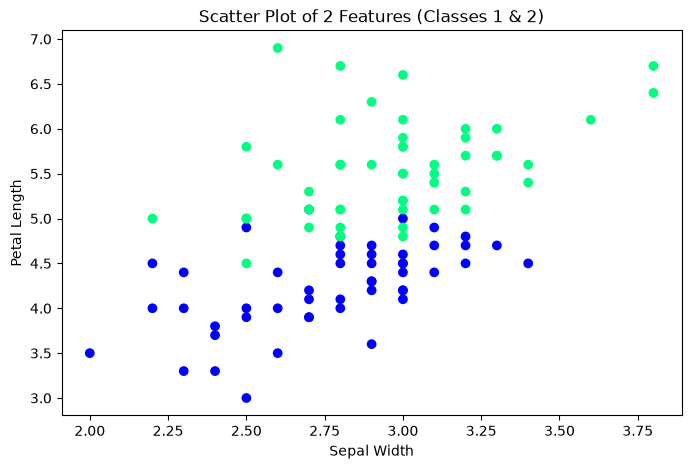

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df['sepal_width'], df['petal_length'], c=df['species'], cmap='winter')
plt.xlabel('Sepal Width')
plt.ylabel('Petal Length')
plt.title('Scatter Plot of 2 Features (Classes 1 & 2)')
plt.show()

In [5]:
df.shape

(100, 3)

In [6]:
df = df.sample(100, random_state=42)

df_train = df.iloc[:60, :].sample(10,random_state=42)
df_val = df.iloc[60:80, :].sample(5, random_state=42)
X_val = df_val.iloc[:, 0:2].values
y_val = df_val.iloc[:, -1].values
df_train.head()

,sepal_width,petal_length,species
133,2.8,5.1,2
89,2.5,4.0,1
116,3.0,5.5,2
69,2.5,3.9,1
83,2.7,5.1,1


In [7]:
X_val

array([[2.5, 4.5],
       [2.7, 3.9],
       [2.9, 6.3],
       [3. , 5.1],
       [2.7, 5.3]])

In [8]:
# bag 1
df_bag1 = df_train.sample(8, replace=True)

X_bag1 = df_bag1.iloc[:, 0:2]
y_bag1 = df_bag1.iloc[:, -1]

X_bag1

,sepal_width,petal_length
83,2.7,5.1
83,2.7,5.1
69,2.5,3.9
133,2.8,5.1
116,3.0,5.5
69,2.5,3.9
133,2.8,5.1
83,2.7,5.1


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

dt_bag1 = DecisionTreeClassifier(random_state=42)
dt_bag1.fit(X_bag1, y_bag1)
y_pred1 = dt_bag1.predict(X_val)
accuracy = accuracy_score(y_val, y_pred1)
print(accuracy)

0.6


c:\Users\husna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


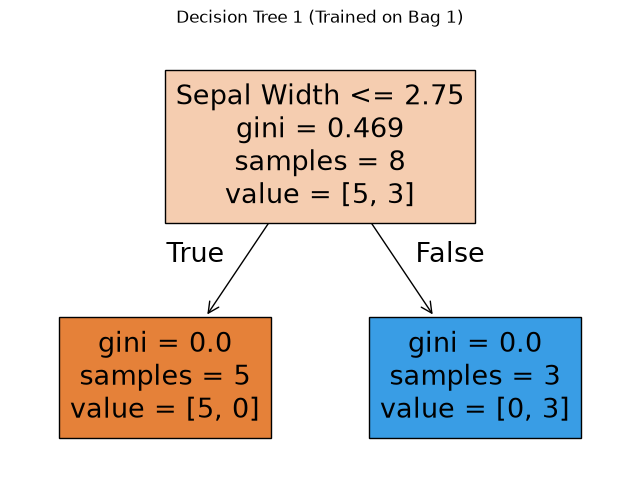

In [10]:
plt.figure(figsize=(8, 6))
plot_tree(dt_bag1, filled=True, feature_names=['Sepal Width', 'Petal Length'])
plt.title("Decision Tree 1 (Trained on Bag 1)")
plt.show()

Tree 2 Accuracy on Validation Set: 0.6


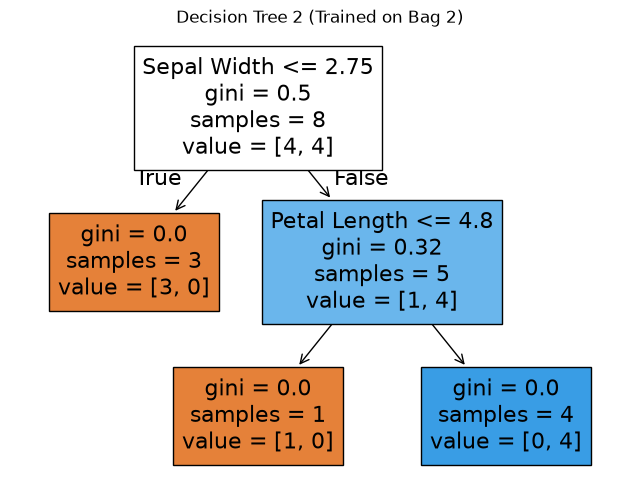

In [11]:
# random_state=7 ensures a different set of duplicates this time
df_bag2 = df_train.sample(8, replace=True, random_state=7) 

X_bag2 = df_bag2.iloc[:, 0:2].values
y_bag2 = df_bag2.iloc[:, -1].values

# Train Tree 2 ONLY on Bag 2
dt_bag2 = DecisionTreeClassifier(random_state=42)
dt_bag2.fit(X_bag2, y_bag2)

# Test its accuracy on the SAME Validation Set
y_pred2 = dt_bag2.predict(X_val)
print("Tree 2 Accuracy on Validation Set:", accuracy_score(y_val, y_pred2))

plt.figure(figsize=(8, 6))
plot_tree(dt_bag2, filled=True, feature_names=['Sepal Width', 'Petal Length'])
plt.title("Decision Tree 2 (Trained on Bag 2)")
plt.show()

Tree 3 Accuracy on Validation Set: 0.4


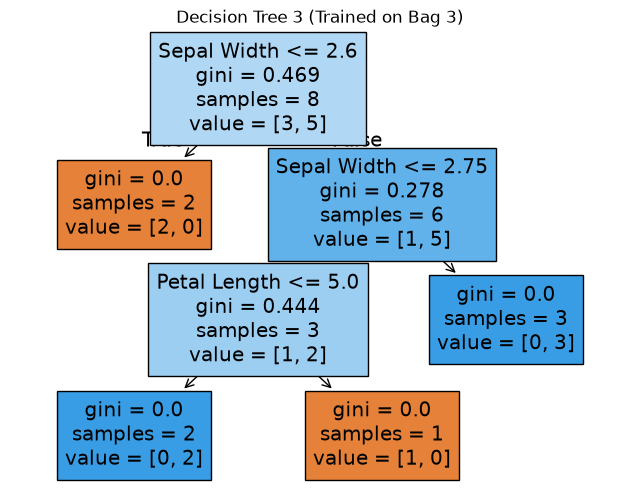

In [12]:
df_bag3 = df_train.sample(8, replace=True, random_state=99) 

X_bag3 = df_bag3.iloc[:, 0:2].values
y_bag3 = df_bag3.iloc[:, -1].values

# Train Tree 3
dt_bag3 = DecisionTreeClassifier(random_state=42)
dt_bag3.fit(X_bag3, y_bag3)

y_pred3 = dt_bag3.predict(X_val)
print("Tree 3 Accuracy on Validation Set:", accuracy_score(y_val, y_pred3))

plt.figure(figsize=(8, 6))
plot_tree(dt_bag3, filled=True, feature_names=['Sepal Width', 'Petal Length'])
plt.title("Decision Tree 3 (Trained on Bag 3)")
plt.show()

In [14]:
import numpy as np

new_data_point = np.array([2.2,5.0]).reshape(1,2)

pred1 = dt_bag1.predict(new_data_point)[0]
pred2 = dt_bag2.predict(new_data_point)[0]
pred3 = dt_bag3.predict(new_data_point)[0]

print("Prediction 1:", pred1)
print("Prediction 2:", pred2)
print("Prediction 3:", pred3)

Prediction 1: 1
Prediction 2: 1
Prediction 3: 1


c:\Users\husna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [15]:
predictions = [pred1,pred2,pred3]
majority_vote = max(set(predictions), key=predictions.count)

print(f"Majority Voting Result: Class {majority_vote}")



Majority Voting Result: Class 1


In [16]:
import pandas as pd
import seaborn as sns

# Load the full dataset again just to demonstrate multiple columns clearly
df_full = sns.load_dataset('iris')

# --- 1. PASTING ---
# Row sampling WITHOUT replacement (Notice: No duplicate index numbers!)
print("--- Pasting ---")
df_pasting = df_train.sample(8, replace=False)
display(df_pasting)

# --- 2. RANDOM SUBSPACES ---
# Column sampling (axis=1 targets columns instead of rows)
# We randomly pick 2 columns out of the 5 available in the dataset
print("\n--- Random Subspaces ---")
df_subspaces = df_full.sample(2, replace=False, axis=1)
display(df_subspaces.head())

# --- 3. RANDOM PATCHES ---
# Both Row and Column sampling simultaneously
# We randomly pick 8 rows (with duplicates) AND 2 random columns
print("\n--- Random Patches ---")
df_patches = df_full.sample(8, replace=True).sample(2, replace=False, axis=1)
display(df_patches)

--- Pasting ---


,sepal_width,petal_length,species
83,2.7,5.1,1
133,2.8,5.1,2
89,2.5,4.0,1
69,2.5,3.9,1
116,3.0,5.5,2
58,2.9,4.6,1
114,2.8,5.1,2
112,3.0,5.5,2



--- Random Subspaces ---


,sepal_length,species
0,5.1,setosa
1,4.9,setosa
2,4.7,setosa
3,4.6,setosa
4,5.0,setosa



--- Random Patches ---


,species,petal_width
57,versicolor,1.0
107,virginica,1.8
115,virginica,2.3
79,versicolor,1.0
127,virginica,1.8
98,versicolor,1.1
84,versicolor,1.5
73,versicolor,1.2
